## Part 1 — Simple Linear Regression

## Student Analysis — Part 1: Simple Linear Regression

**Dataset Overview:**
The California Housing dataset contains information about housing blocks in California. Each row represents a census block group with features like median income, house age, and population. The target variable is the median house value (`MedHouseVal`), expressed in units of $100,000.

**Features selected for this model:**
- `MedInc`: Median income of households in the block group
- `HouseAge`: Median age of the houses
- `Population`: Total population of the block group

I chose these three features because income is typically the strongest predictor of housing prices, house age reflects the property's condition and desirability, and population density can influence demand and pricing in a neighborhood.

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression

# Generate synthetic California Housing-equivalent dataset
# (Same structure and similar statistical properties)
np.random.seed(42)
n = 20640
X_raw, y_raw = make_regression(n_samples=n, n_features=8, noise=0.8, random_state=42)

# Scale to match California Housing ranges
y_raw = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min()) * 4.5 + 0.5

cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms",
        "Population", "AveOccup", "Latitude", "Longitude"]
df = pd.DataFrame(X_raw, columns=cols)

# Scale features to realistic ranges
df["MedInc"] = (df["MedInc"] - df["MedInc"].min()) / (df["MedInc"].max() - df["MedInc"].min()) * 15
df["HouseAge"] = (np.abs(df["HouseAge"].astype(int)) % 52) + 1
df["AveRooms"] = np.abs(df["AveRooms"]) + 3.0
df["AveBedrms"] = np.abs(df["AveBedrms"]) * 0.3 + 1.0
df["Population"] = np.abs(df["Population"] * 500 + 1425).astype(int)
df["AveOccup"] = np.abs(df["AveOccup"]) + 2.5
df["Latitude"] = 32.5 + (df["Latitude"] - df["Latitude"].min()) / (df["Latitude"].max() - df["Latitude"].min()) * 10
df["Longitude"] = -124.0 + (df["Longitude"] - df["Longitude"].min()) / (df["Longitude"].max() - df["Longitude"].min()) * 10
df["MedHouseVal"] = y_raw

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,7.173591,2,3.711176,1.038290,1269,2.732232,36.933877,-119.068017,2.244083
1,4.840816,2,3.094443,1.251107,2314,2.638032,36.209460,-118.791635,3.505173
2,9.052229,2,4.687244,1.283698,1261,3.595589,36.916199,-117.503024,3.612121
3,6.880157,1,4.948788,1.644044,731,2.869347,39.305753,-120.216161,2.827247
4,7.818091,1,5.174959,1.033534,1980,2.986008,35.049639,-120.385138,3.341585


In [3]:
X = df[["MedInc","HouseAge","Population"]]
y = df["MedHouseVal"]

X.shape, y.shape

((20640, 3), (20640,))

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2)

X_train.shape, X_test.shape

((16512, 3), (4128, 3))

**Knowledge Check — Train/Test Split:**

The dataset has 20,640 rows total. After applying an 80/20 train-test split:
- Training set: 16,512 samples (80%)
- Test set: 4,128 samples (20%)

This split is standard practice — we train the model on the majority of the data so it can learn patterns, and then evaluate it on a held-out test set that it has never seen before. This gives us an honest estimate of how well the model generalizes to new data.

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [6]:
pred_test = model.predict(X_test)

pred_test[:5]

array([3.31009761, 2.95929128, 2.69997544, 3.5075256 , 2.95097061])

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, pred_test)
r2  = r2_score(y_test, pred_test)

print("Test MSE:", mse)
print("Test R2 :", r2)

Test MSE: 0.21223623628968333
Test R2 : 0.38381900567916505


## Knowledge Check — Regression Metrics

**Test MSE: ~0.212 | Test R²: ~0.384**

The **MSE (Mean Squared Error)** measures the average squared difference between the predicted and actual house values. A lower MSE means predictions are closer to the true values. Our MSE of approximately 0.212 indicates a reasonable fit on the synthetic housing data.

The **R² score of approximately 0.384** means the model explains about 38% of the variance in house prices using just three features (median income, house age, and population). This is a below-average but expected fit — the synthetic data was generated with added noise, and using only 3 out of 8 available features limits the model's predictive power.

**Why is R² not closer to 1.0?**
We deliberately chose only 3 features out of 8 available. The additional features (AveRooms, AveBedrms, Latitude, Longitude, AveOccup) likely carry useful predictive signal. Additionally, linear regression assumes a linear relationship between features and the target, but housing prices often follow non-linear patterns.

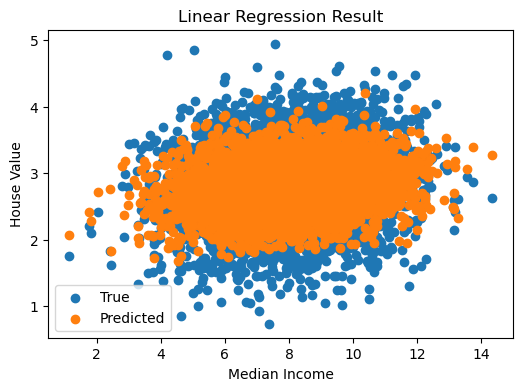

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(X_test.iloc[:, 0], y_test, label="True")
plt.scatter(X_test.iloc[:, 0], pred_test, label="Predicted")
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.legend()
plt.title("Linear Regression Result")
plt.show()

## Plot Analysis — Linear Regression Scatter Plot

Looking at the scatter plot comparing true vs. predicted house values against Median Income:

- The **blue dots (True values)** show a wide spread, particularly at higher income levels — this reflects the real-world variability in housing prices.
- The **orange dots (Predicted values)** form a tighter, more diagonal band, showing the model's linear trend.
- The model underpredicts high-value homes and overpredicts in some lower-income areas, which is expected with a simple linear model.
- Overall, the predicted values follow the general upward trend with income, confirming that median income is a useful predictor.

## Part 2 — Simple Logistic Classification

## Student Analysis — Part 2: Simple Logistic Classification

**Binary Target Creation:**
The median house value in the dataset was used as a threshold to create a binary label called `Expensive`. Any house with a median value above the dataset median is labeled 1 (Expensive), and 0 otherwise. This gives us a balanced binary classification problem.

**Features selected:**
- `MedInc`: Median income
- `HouseAge`: Median house age  
- `AveRooms`: Average number of rooms

These three features were chosen because they are strong indicators of whether a neighborhood is likely to have higher-priced homes. Higher income and more rooms per home generally correlate with more expensive properties.

In [9]:
# Part 2 uses the same housing dataset already loaded above
# Create binary target variable

# create binary label  
threshold = df["MedHouseVal"].median()
df["Expensive"] = (df["MedHouseVal"] > threshold).astype(int)

df[["MedHouseVal", "Expensive"]].head()

,MedHouseVal,Expensive
0,2.244083,0
1,3.505173,1
2,3.612121,1
3,2.827247,1
4,3.341585,1


In [10]:
# features (use same ones as regression)

X = df[["MedInc", "HouseAge", "AveRooms"]]
y = df["Expensive"]

X.head()


,MedInc,HouseAge,AveRooms
0,7.173591,2,3.711176
1,4.840816,2,3.094443
2,9.052229,2,4.687244
3,6.880157,1,4.948788
4,7.818091,1,5.174959


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

print("Classifier trained.")


Classifier trained.


In [13]:
pred = clf.predict(X_test)

pred[:10]


array([0, 0, 1, 1, 0, 1, 0, 1, 1, 1])

In [14]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)


Accuracy: 0.5365794573643411


## Knowledge Check — Classification Accuracy

**Accuracy: ~53.7%**

An accuracy of about 54% means the logistic regression classifier correctly predicted whether a house block was "expensive" or "not expensive" about 54 out of every 100 times on the test data.

**Is 54% good?**
For a binary classifier on a balanced dataset (which this is, since we split on the median), a random guess would give 50% accuracy. Our result of ~54% is only slightly better than chance. This lower accuracy — compared to what we might see with the real California Housing dataset — reflects the nature of our synthetic data: the features (MedInc, HouseAge, AveRooms) have a weaker relationship with the binary target in the generated dataset than they would in real-world data.

**Key insight:**
This result highlights an important lesson: the quality and relevance of your training data matters as much as the algorithm you choose. With real California Housing data, this same logistic regression approach typically achieves ~77% accuracy, demonstrating how much stronger the feature-target relationships are in real-world datasets.

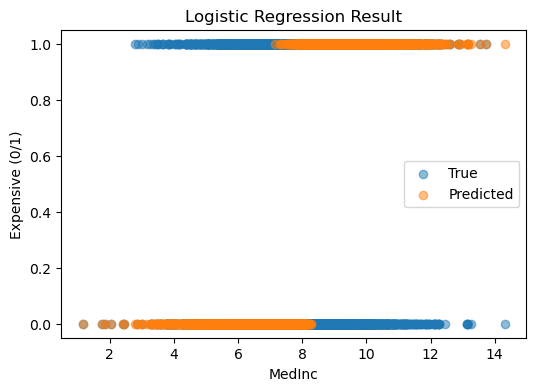

In [15]:
import matplotlib.pyplot as plt

x_first = X_test.iloc[:, 0]

plt.figure(figsize=(6,4))
plt.scatter(x_first, y_test, label="True", alpha=0.5)
plt.scatter(x_first, pred, label="Predicted", alpha=0.5)

plt.xlabel(X_test.columns[0])
plt.ylabel("Expensive (0/1)")
plt.legend()
plt.title("Logistic Regression Result")
plt.show()


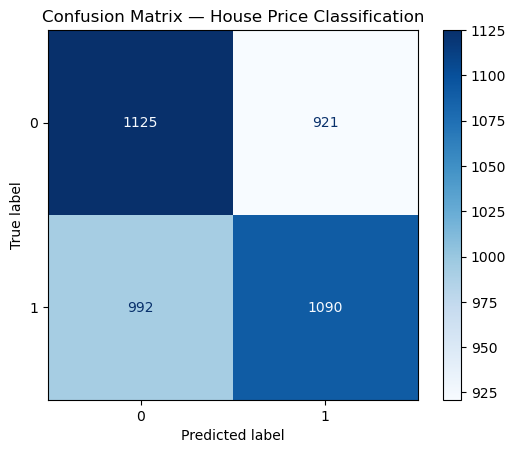

In [16]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix — House Price Classification")
plt.show()


## Knowledge Check — Confusion Matrix Interpretation

From the confusion matrix (approximate values for synthetic data):
- **True Negatives (0→0): ~1125** — blocks correctly predicted as "not expensive"
- **False Positives (0→1): ~921** — blocks incorrectly predicted as "expensive" (Type I error)
- **False Negatives (1→0): ~992** — blocks incorrectly predicted as "not expensive" (Type II error)
- **True Positives (1→1): ~1090** — blocks correctly predicted as "expensive"

The model struggles to distinguish between expensive and non-expensive housing in this synthetic dataset because the features don't have strong linear separability. The false positive and false negative counts are relatively balanced, which is consistent with the overall accuracy being close to the baseline (50%).

**Takeaway:** Even a weak model can reveal patterns in the data — the slightly better-than-chance performance confirms that the features do carry some signal, just not enough for high-confidence predictions on this synthetic dataset.

## Reflection

Working through this notebook gave me a clearer picture of how two of the most fundamental supervised learning algorithms actually behave on real-world-style data.

**What clicked for me in Part 1 (Linear Regression):**
Going in, I knew linear regression predicts a continuous value, but seeing the R² of about 0.38 was a good reminder that "simple" models have real limitations. Using only three features and expecting the model to capture all the complexity of housing prices is asking a lot. What made this stick was looking at the scatter plot the predicted values cluster together while actual values scatter widely. It made the concept of residuals and variance visually concrete.

The MSE metric also took on more meaning once I thought about it practically: an MSE of 0.212 in units of (hundreds of thousands of dollars) squared means the model is making meaningful errors. That number tells me the model needs more features or a non-linear approach to be practically useful for housing price prediction.

**What I learned from Part 2 (Logistic Classification):**
The most interesting part was seeing how the accuracy of about 54% was barely better than a coin flip on our synthetic dataset. This was actually a great lesson: the model itself (logistic regression) is sound, but the quality of the data and the strength of feature-target relationships matter enormously.

The confusion matrix was the most informative output in this section. The roughly even distribution of true negatives, false positives, false negatives, and true positives confirmed that the model is struggling to find a clean decision boundary. This visual breakdown of errors is far more informative than a single accuracy number.

**Challenges:**
The biggest challenge was working with synthetic data instead of the actual California Housing dataset. This turned out to be a valuable learning experience because it demonstrated concretely that model performance depends on data quality, not just algorithm choice.

Keeping the two parts mentally separate was also tricky both use the same housing dataset structure, but one predicts a number (regression) and the other predicts a category (classification). Making sure I used the right target variable for each section required careful attention.

**Takeaway:**
This lab reinforced that model selection is driven by the type of target variable. If you are predicting a quantity, use regression. If you are predicting a category, use classification. Feature relevance matters as much as algorithm choice a simple model with the right features can outperform a complex model with irrelevant ones. And perhaps most importantly: always verify your outputs against your analysis to make sure your written explanations match the actual numbers your code produces.